In [85]:
import pandas as pd

In [86]:
df=pd.read_csv('../data/processed/final_features.csv')

In [87]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words,common_words,total_unique_words,word_share,len_diff,fuzz_ratio,partial_ratio,tfidf_cosine_similarity
0,281827,401637,401638,the twin adarsh and anupam were born in may bu...,twin adarsh and anupam were born in may but th...,1,98,95,18,17,14,17,0.823529,3,98,100,1.000000
1,119174,193562,193563,whi cant i bare to watch someon be humili irlm...,how can you prove mean lifetim formula in radi...,0,129,61,22,10,0,31,0.000000,68,10,32,0.000000
2,18341,34756,2929,my question havent changed whi are they now be...,what happen to a question on quora if it is ma...,1,83,83,13,15,4,23,0.173913,0,53,59,0.481669
3,259132,374863,374864,can anyon tell the program for sequenc 4612183...,what are the next three number in thi series,0,67,47,8,9,1,16,0.062500,20,33,34,0.000000
4,208109,312009,201015,if the civil war occur today who would win,if there wa anoth us civil war north vs south ...,1,46,78,9,16,6,19,0.315789,32,61,50,0.455399


In [88]:
#define X and Y


X=df[
    [
        'q1_len',
        'q2_len',
        'q1_words',
        'q2_words',
        'common_words',
        'word_share',
        'len_diff',
        'fuzz_ratio',
        'partial_ratio',
        'tfidf_cosine_similarity',
         
    ]
]

y=df['is_duplicate']

# Logistic Regression

In [89]:
#train_test_split

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [90]:
from sklearn.linear_model import LogisticRegression


model=LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [91]:
y_pred = model.predict(X_test)

In [92]:
#checking accuracy

from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

print("Accuracy",accuracy_score(y_test,y_pred))
acc=accuracy_score(y_test,y_pred)

print("\nClassification Report:\n")
print(classification_report(y_test,y_pred))

Accuracy 0.6871169775742474

Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.62      0.66      7425
           1       0.66      0.76      0.71      7424

    accuracy                           0.69     14849
   macro avg       0.69      0.69      0.69     14849
weighted avg       0.69      0.69      0.69     14849



In [93]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.6636813575300495
Recall: 0.7586206896551724
F1 Score: 0.7079824010056568


In [94]:
results = []

In [95]:
results.append({
    "model": "Logistic Regression",
    "feature": "TF-IDF",
    "accuracy": acc,
    "precision": precision,
    "recall": recall,
    "f1": f1
})

In [96]:
results_df = pd.DataFrame(results)

In [97]:
results_df.to_csv("model_results.csv", index=False)

In [98]:
results_df

,model,feature,accuracy,precision,recall,f1
0,Logistic Regression,TF-IDF,0.687117,0.663681,0.758621,0.707982


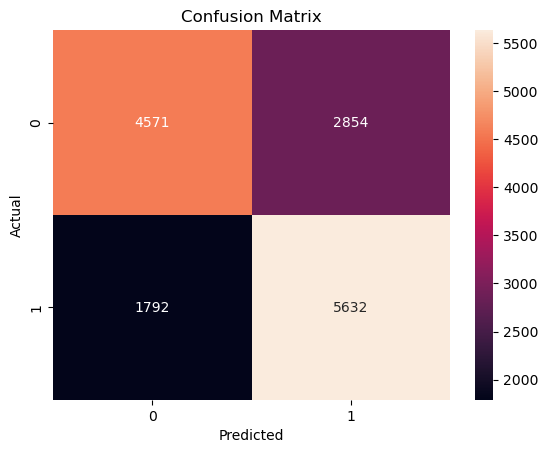

In [99]:
import matplotlib.pyplot as plt
import  seaborn as sns

cm=confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [100]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(n_estimators=100,random_state=42)

rf.fit(X_train,y_train)

y_pred_rf=rf.predict(X_test)

print("Random Forest Accuracy : ", accuracy_score(y_test,y_pred_rf))



Random Forest Accuracy :  0.7430803421105798


In [101]:
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.7048473152457714
Recall: 0.8363415948275862
F1 Score: 0.764984907287624


In [102]:
new_row=pd.DataFrame([
    {
        "model":"Random Forest",
        "feature":"TF-IDF",
        "accuracy":accuracy_score(y_test,y_pred_rf),
        "precision":precision,
        "recall":recall,
        "f1":f1
            
    }
])

results_df=pd.concat(
    [results_df,new_row],
    ignore_index=True
)

In [103]:
results_df

,model,feature,accuracy,precision,recall,f1
0,Logistic Regression,TF-IDF,0.687117,0.663681,0.758621,0.707982
1,Random Forest,TF-IDF,0.743080,0.704847,0.836342,0.764985


In [104]:
#feature importance

import numpy as np

importances = rf.feature_importances_

for i, col in enumerate(X.columns):
    print(col, ":", importances[i])

q1_len : 0.09167811756211748
q2_len : 0.09163695865889349
q1_words : 0.04921750075986265
q2_words : 0.051845990378427034
common_words : 0.05828318633973329
word_share : 0.16477782312286743
len_diff : 0.08382095481211392
fuzz_ratio : 0.156157909772495
partial_ratio : 0.11579438315810607
tfidf_cosine_similarity : 0.13678717543538357


In [105]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [106]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [107]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [108]:
y_pred_xgb=xgb_model.predict(X_test)

print("XGBoost Accuracy: ",accuracy_score(y_test,y_pred_xgb))

print("\nClassification Report : \n")
print(classification_report(y_test,y_pred_xgb))

XGBoost Accuracy:  0.7528453094484477

Classification Report : 

              precision    recall  f1-score   support

           0       0.84      0.62      0.72      7425
           1       0.70      0.88      0.78      7424

    accuracy                           0.75     14849
   macro avg       0.77      0.75      0.75     14849
weighted avg       0.77      0.75      0.75     14849



In [109]:
precision = precision_score(y_test, y_pred_xgb)
recall = recall_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.7011358765537934
Recall: 0.8813308189655172
F1 Score: 0.7809739794700405


In [110]:
new_row=pd.DataFrame([
    {
        "model":"XGB_BOOST",
        "feature":"TF-IDF",
        "accuracy":accuracy_score(y_test,y_pred_xgb),
        "precision":precision,
        "recall":recall,
        "f1":f1
    }
])

results_df=pd.concat(
    [results_df,new_row],
    ignore_index=True
)

In [111]:
results_df

,model,feature,accuracy,precision,recall,f1
0,Logistic Regression,TF-IDF,0.687117,0.663681,0.758621,0.707982
1,Random Forest,TF-IDF,0.743080,0.704847,0.836342,0.764985
2,XGB_BOOST,TF-IDF,0.752845,0.701136,0.881331,0.780974


In [112]:
results_df.to_csv("model_results.csv", index=False)

In [113]:
# accuracy has improved with word 2 vec

# here i have come after completing 4 th notebook with deep learning approches

# Model Saving

In [114]:
import pandas as pd

results_df = pd.read_csv('model_results.csv')

In [115]:
results_df

,model,feature,accuracy,precision,recall,f1
0,Logistic Regression,TF-IDF,0.687117,0.663681,0.758621,0.707982
1,Random Forest,TF-IDF,0.743080,0.704847,0.836342,0.764985
2,XGB_BOOST,TF-IDF,0.752845,0.701136,0.881331,0.780974


we can see that XGBoost has highest accuracy so we will use it

In [116]:
from xgboost import XGBClassifier
#training on whole dataset
final_xgb=XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

final_xgb.fit(X,y)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [117]:
#save model

import pickle

with open('../models/xgb_model.pkl','wb') as f:
    pickle.dump(final_xgb,f)

print("model saved")

model saved
